### 1. Comprendre le dataset

In [1]:
import pandas as pd 

data = pd.read_excel("c:/Users/Youcode/Desktop/SegmentIQ/data/data.xlsx")

In [ ]:
display(data.head())


kanchofo hnaya bli 3ndna chi columns fihom deplucated dyal customerID o kola row kaymetel dakchi li khda achat dyal client

In [ ]:
display(data.tail())


hnaya kanchofo bli kaynin chi customerID li 3ndhom valeur NaN fl ID donc khass it7iyedo 

In [ ]:
display(data.shape)


hnaya kanchofo bli 3ndna 541909 rows fhad data o 8 columns

In [ ]:
display(data.info())


hnaya kanl9aw bli man7tajoch n convertiw type dyal chi columns 7it deja m9adin 

In [ ]:
display(data.dtypes)


même chose 

In [ ]:
display(data.describe())

hnaya kanchofo bli customerID na9ssin bzaf 3la invoicedata o uniteprice o quantity
o bli kaynin valeur fl quantity o unitprice li negative

### 2. Comprendre les variables

In [7]:
print(data.columns.to_list())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
print(data.nunique())

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


In [3]:
display(data.dtypes.to_frame("Type informatique"))

,Type informatique
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str


In [4]:
display(data.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
display(data.dtypes.to_frame("Type informatique"))

,Type informatique
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str


### 3. Qualité des données

**A. Objectif**
Identifier les anomalies : valeurs manquantes, doublons et valeurs absurdes.

**D. Observation**
- ~25% des CustomerID sont manquants.
- ~5268 doublons exacts.
- 10624 retours (quantités négatives).

**E. Interprétation métier**
Les clients anonymes ne peuvent pas être segmentés. Les retours faussent le CA.

**F. Décision**
- Supprimer doublons et CustomerID manquant.
- Ne garder que Quantity > 0 et UnitPrice > 0.\n

In [ ]:
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({'Valeurs Manquantes': missing_values, 'Pourcentage (%)': missing_percent})
display(missing_df[missing_df['Valeurs Manquantes'] > 0].sort_values(by='Pourcentage (%)', ascending=False))

print("Nombre de lignes exactement identiques :", data.duplicated().sum())


print("Nombre de transactions avec quantité négative :", (data['Quantity'] < 0).sum())
print("Prix unitaire nul ou négatif :", (data['UnitPrice'] <= 0).sum())

cancelled_orders = data['InvoiceNo'].astype(str).str.startswith('C').sum()
print("Nombre de factures annulées :", cancelled_orders)

--- Valeurs manquantes ---


,Valeurs Manquantes,Pourcentage (%)
CustomerID,135080,24.926694
Description,1454,0.268311


Nombre de lignes exactement identiques : 5268
Nombre de transactions avec quantité négative : 10624
Prix unitaire nul ou négatif : 2517
Nombre de factures annulées : 9288


### Transition : Nettoyage des données (Data Cleaning)\n

In [6]:
# 1. Copie du dataset sans les doublons
data_clean = data.drop_duplicates().copy()

# 2. Suppression des clients anonymes (indispensable pour RFM)
data_clean.dropna(subset=['CustomerID'], inplace=True)

# 3. Filtrage des annulations, retours et prix nuls
data_clean = data_clean[(data_clean['Quantity'] > 0) & (data_clean['UnitPrice'] > 0)]

print(f"Dimensions avant nettoyage : {data.shape}")
print(f"Dimensions après nettoyage : {data_clean.shape}")
print(data.head())

Dimensions avant nettoyage : (541909, 8)
Dimensions après nettoyage : (392692, 8)
  InvoiceNo StockCode                       Description  Quantity  \
0    554065     22755   SMALL PURPLE BABUSHKA NOTEBOOK         12   
1    554065     22754      SMALL RED BABUSHKA NOTEBOOK         12   
2    554065     22753   SMALL YELLOW BABUSHKA NOTEBOOK         12   
3    554065     22756   LARGE YELLOW BABUSHKA NOTEBOOK         12   
4    554065     22758  LARGE PURPLE BABUSHKA NOTEBOOK          12   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2011-05-22 10:39:00       0.85     18287.0  United Kingdom  
1 2011-05-22 10:39:00       0.85     18287.0  United Kingdom  
2 2011-05-22 10:39:00       0.85     18287.0  United Kingdom  
3 2011-05-22 10:39:00       1.25     18287.0  United Kingdom  
4 2011-05-22 10:39:00       1.25     18287.0  United Kingdom  


### 4. Analyse univariée

#### 1. Variables catégorielles (`Country` et `Description`)
**A. Objectif** — Découvrir d'où viennent nos clients et quels sont les produits phares.

**D. Observation**
- Le Royaume-Uni écrase les autres pays.
- Les produits stars reviennent très souvent.

**E. Interprétation métier**
Pour le RFM, séparer le UK du reste du monde pourrait être intéressant.\n

C:\Users\Youcode\AppData\Local\Temp\ipykernel_33900\3843659209.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis", ax=ax[0])
C:\Users\Youcode\AppData\Local\Temp\ipykernel_33900\3843659209.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="mako", ax=ax[1])


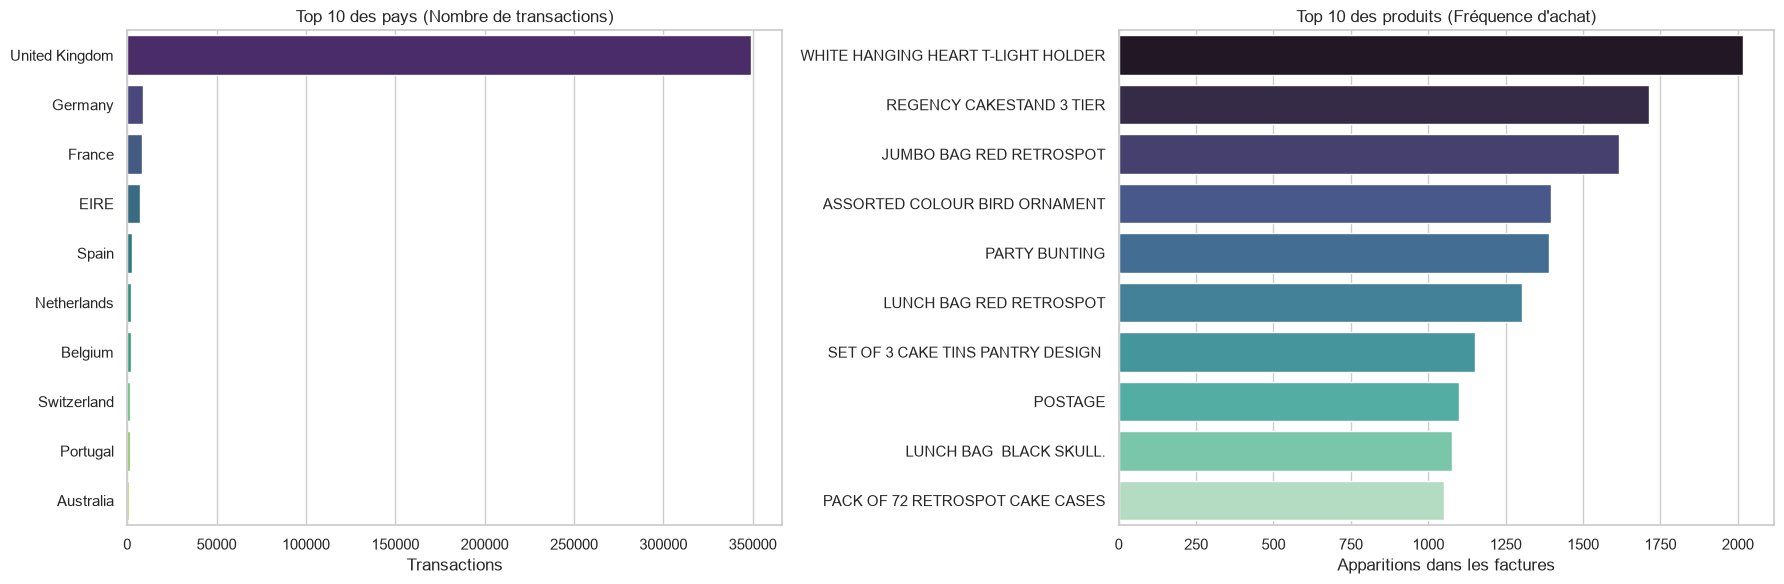

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

top_countries = data_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis", ax=ax[0])
ax[0].set_title("Top 10 des pays (Nombre de transactions)")
ax[0].set_xlabel("Transactions")
ax[0].set_ylabel("")

top_products = data_clean['Description'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette="mako", ax=ax[1])
ax[1].set_title("Top 10 des produits (Fréquence d'achat)")
ax[1].set_xlabel("Apparitions dans les factures")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

#### 2. Variables numériques (`Quantity` et `UnitPrice`)
**A. Objectif** — Comprendre les volumes et prix.

**D. Observation**
- Majorité d'achats en petites quantités.
- Prix unitaires bas (majorité < 5£).

**E. Interprétation métier**
Forte présence B2C avec des outliers énormes qui correspondent sans doute à du B2B. L'algorithme K-Means sera sensible à ces extrêmes.\n

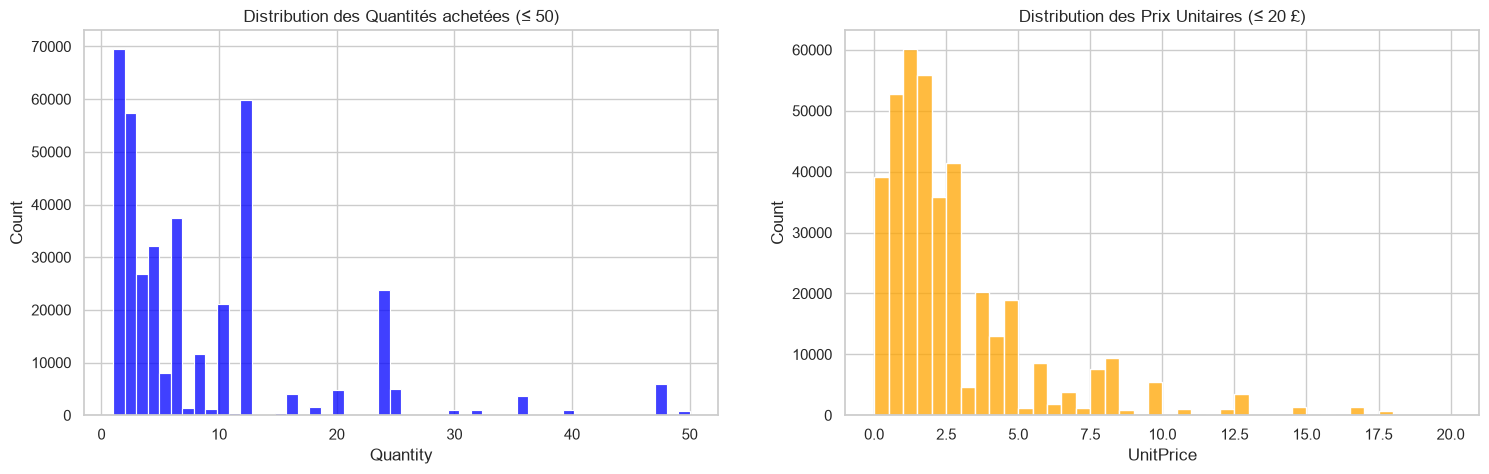

,Quantity,UnitPrice
count,392692.000000,392692.000000
mean,13.119702,3.125914
std,180.492832,22.241836
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data_clean[data_clean['Quantity'] <= 50]['Quantity'], bins=50, ax=ax[0], color='blue')
ax[0].set_title("Distribution des Quantités achetées (≤ 50)")

sns.histplot(data_clean[data_clean['UnitPrice'] <= 20]['UnitPrice'], bins=40, ax=ax[1], color='orange')
ax[1].set_title("Distribution des Prix Unitaires (≤ 20 £)")

plt.show()

display(data_clean[['Quantity', 'UnitPrice']].describe())

### Étape 5 — Analyse temporelle

**A. Objectif**
Étudier l'évolution des transactions et du chiffre d'affaires dans le temps pour identifier des tendances ou des saisonnalités.

**C. Explication**
- `.dt.to_period('M')` et `.dt.day_name()` permettent d'extraire le mois et le jour de la semaine à partir de `InvoiceDate`.
- Nous calculons d'abord le `Revenue` (Chiffre d'Affaires) = Quantité × Prix Unitaire.
- Nous utilisons des graphiques en courbes (line plot) pour suivre l'évolution temporelle.

**D. Observation**
- **Ventes mensuelles :** On remarque une forte croissance des ventes à partir d'Août, avec un pic énorme en Novembre. Décembre semble bas, mais c'est parce que le jeu de données s'arrête début décembre (il manque la fin du mois).
- **Jours de la semaine :** Le jeudi et mardi sont les plus actifs. Fait très surprenant : il n'y a **aucune transaction le Samedi (Saturday)**.

**F. Décision**
- Nous conserverons `InvoiceDate` précieusement. Elle nous servira à calculer la "Récence" (le 'R' du modèle RFM) en déterminant le nombre de jours écoulés depuis le dernier achat de chaque client.\n

       InvoiceNo StockCode                          Description  Quantity  \
0         554065     22755      SMALL PURPLE BABUSHKA NOTEBOOK         12   
1         554065     22754         SMALL RED BABUSHKA NOTEBOOK         12   
2         554065     22753      SMALL YELLOW BABUSHKA NOTEBOOK         12   
3         554065     22756      LARGE YELLOW BABUSHKA NOTEBOOK         12   
4         554065     22758     LARGE PURPLE BABUSHKA NOTEBOOK          12   
...          ...       ...                                  ...       ...   
406823    581180     21265         PINK GOOSE FEATHER TREE 60CM        12   
406824    581180     23271  CHRISTMAS TABLE SILVER CANDLE SPIKE        16   
406825    581180     23506         MINI PLAYING CARDS SPACEBOY         20   
406826    581180     23508       MINI PLAYING CARDS DOLLY GIRL         20   
406827    541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   

               InvoiceDate  UnitPrice  CustomerID         Country MonthYear

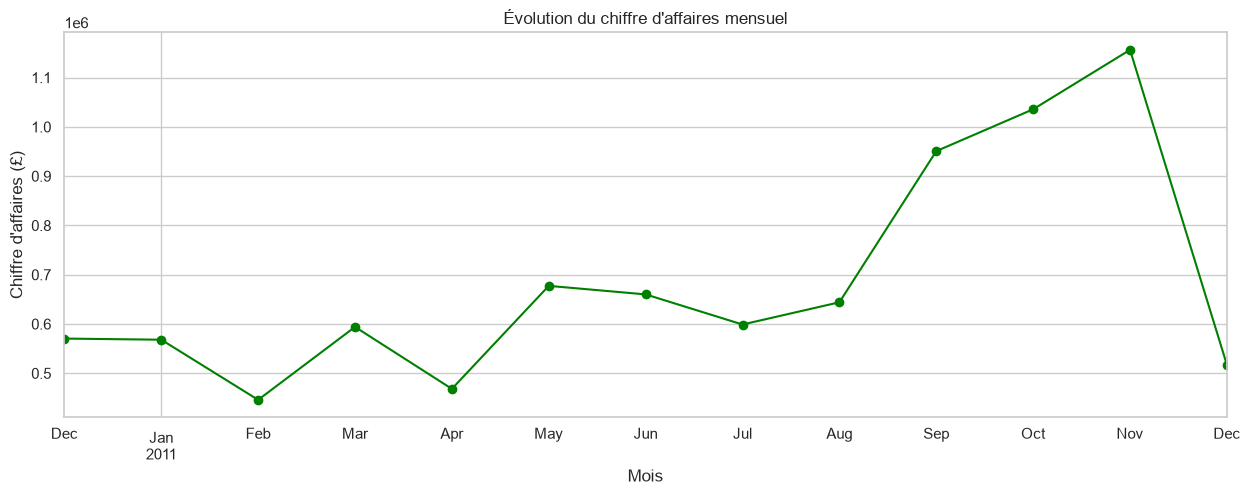

C:\Users\Youcode\AppData\Local\Temp\ipykernel_33900\2567960716.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_invoices.index, y=daily_invoices.values, palette="cubehelix")


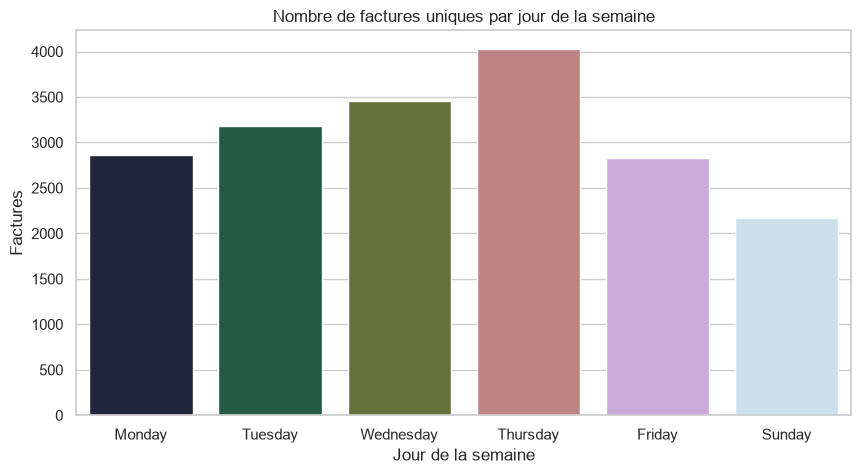

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_clean['MonthYear'] = data_clean['InvoiceDate'].dt.to_period('M')
data_clean['DayOfWeek'] = data_clean['InvoiceDate'].dt.day_name()
data_clean['Revenue'] = data_clean['Quantity'] * data_clean['UnitPrice']
print(data_clean)

monthly_revenue = data_clean.groupby('MonthYear')['Revenue'].sum()
print(monthly_revenue)
plt.figure(figsize=(15, 5))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
daily_invoices = data_clean.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(days_order)
sns.barplot(x=daily_invoices.index, y=daily_invoices.values, palette="cubehelix")
plt.title("Nombre de factures uniques par jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Factures")
plt.show()

### Étape 6 — Analyse bivariée et relations entre variables

**A. Objectif**
Voir la relation entre le Prix et la Quantité, et comparer le CA par Pays.

**D. Observation**
- UK est le premier marché en chiffre d'affaires. Netherlands et EIRE sont très rentables.
- Plus le prix unitaire est élevé, plus la quantité achetée est petite.

**E. Interprétation métier**
- La règle classique de la demande est respectée. 
- Les pays d'export génèrent beaucoup de CA et méritent une segmentation spécifique.\n

C:\Users\Youcode\AppData\Local\Temp\ipykernel_33900\807167854.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette="viridis", ax=ax[0])


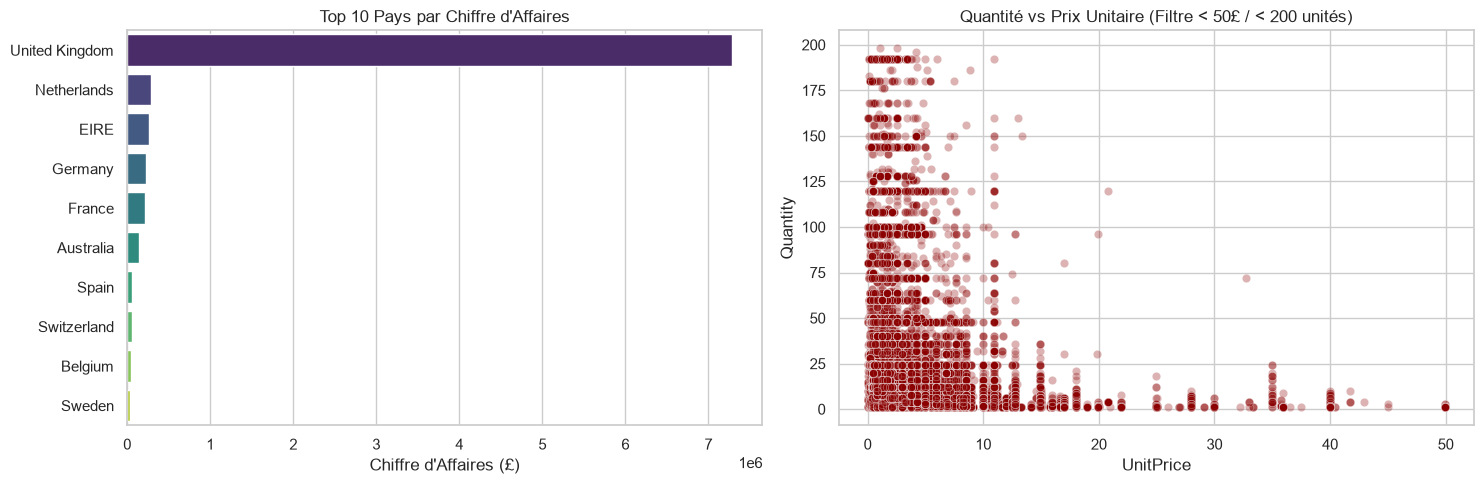

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

country_revenue = data_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette="viridis", ax=ax[0])
ax[0].set_title("Top 10 Pays par Chiffre d'Affaires")
ax[0].set_xlabel("Chiffre d'Affaires (£)")
ax[0].set_ylabel("")

sns.scatterplot(data=data_clean[(data_clean['UnitPrice'] < 50) & (data_clean['Quantity'] < 200)], x='UnitPrice', y='Quantity', alpha=0.3, ax=ax[1], color="darkred")
ax[1].set_title("Quantité vs Prix Unitaire (Filtre < 50£ / < 200 unités)")

plt.tight_layout()
plt.show()

### Étape 7 — Analyse métier

**A. Objectif**
Extraire les KPIs (Key Performance Indicators) globaux pour avoir une vue d'ensemble du business.

**D. Observation**
- L'entreprise génère un chiffre d'affaires très important avec une base client solide.
- Le panier moyen (Average Order Value) et les revenus par client sont de bonnes métriques.

**E. Interprétation métier**
- Ces KPIs (Fréquence d'achat par client et CA par client) sont exactement les variables que nous allons préparer pour notre modèle RFM.\n

In [ ]:
total_clients = data_clean['CustomerID'].nunique()
total_factures = data_clean['InvoiceNo'].nunique()
total_produits = data_clean['StockCode'].nunique()
total_ca = data_clean['Revenue'].sum()

panier_moyen = total_ca / total_factures
factures_par_client = total_factures / total_clients
ca_par_client = total_ca / total_clients

print("=== KPIs Globaux ===")
print(f"Nombre de clients distincts : {total_clients}")
print(f"Nombre de factures distinctes : {total_factures}")
print(f"Nombre de produits distincts : {total_produits}")
print(f"Chiffre d'affaires global : £{total_ca:,.2f}")

print("\n
=== KPIs Moyens ===")
print(f"Panier moyen par facture : £{panier_moyen:.2f}")
print(f"Nombre moyen de factures par client : {factures_par_client:.2f}")
print(f"Chiffre d'affaires moyen par client : £{ca_par_client:.2f}")

print("\n
=== Top 3 Produits par Chiffre d'Affaires ===")
top_ca_produits = data_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(3)
for prod, ca in top_ca_produits.items():
    print(f"- {prod} : £{ca:,.2f}")\n

### Étape 8 — Détection et analyse des valeurs atypiques

**A. Objectif**
Identifier les valeurs extrêmes (Outliers) qui pourraient biaiser l'algorithme K-Means.

**D. Observation**
- Les Boxplots montrent des valeurs extrêmes énormes pour Quantity (jusqu'à 80000) et UnitPrice (jusqu'à 8000).

**E. Interprétation métier**
- Ces valeurs ne sont pas forcément des erreurs, mais des commandes B2B exceptionnelles (grossistes).

**F. Décision**
- Pour la segmentation RFM K-Means, il sera indispensable d'appliquer une transformation (ex: Log transformation) ou de plafonner (capping) ces valeurs, sinon ces gros clients écraseront les autres segments.\n

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=data_clean['Quantity'], ax=ax[0], color='lightblue')
ax[0].set_title("Boxplot - Quantité")

sns.boxplot(x=data_clean['UnitPrice'], ax=ax[1], color='lightgreen')
ax[1].set_title("Boxplot - Prix Unitaire")

plt.tight_layout()
plt.show()

q99_quant = data_clean['Quantity'].quantile(0.99)
q99_price = data_clean['UnitPrice'].quantile(0.99)

print(f"99% des commandes ont une quantité inférieure ou égale à : {q99_quant}")
print(f"99% des produits ont un prix unitaire inférieur ou égal à : £{q99_price}")

### Étape 9 — Synthèse de l'EDA

L'Analyse Exploratoire des Données (EDA) nous a permis de tirer les conclusions suivantes :
1. **Qualité des données** : Le dataset contenait environ 25% de transactions sans `CustomerID`, ainsi que des doublons et des factures annulées. Nous avons nettoyé ces anomalies pour obtenir un dataset fiable de ~392,000 lignes.
2. **Profil des clients** : L'immense majorité des ventes est réalisée au Royaume-Uni. Les clients achètent principalement des produits de décoration à des prix unitaires très bas (la majorité sous 5£).
3. **Tendances temporelles** : L'activité est soumise à une très forte saisonnalité avec un pic majeur entre septembre et novembre.
4. **Valeurs atypiques** : La présence de comportements d'achats extrêmes (commandes B2B massives) nécessite une transformation des données avant d'appliquer K-Means.\n

### Étape 10 — Préparation à la segmentation RFM

Pour passer à l'étape suivante (Machine Learning avec K-Means), nous devons transformer nos données transactionnelles en **données centrées sur le client**.

Nous allons créer une nouvelle table où **chaque ligne représente un client unique**, avec 3 colonnes :
- **Récence (R)** : Nombre de jours écoulés depuis le dernier achat du client (par rapport à la date la plus récente du dataset).
- **Fréquence (F)** : Nombre total de factures uniques passées par le client.
- **Montant (M)** : Somme totale dépensée par le client (Chiffre d'affaires).

Une fois ces indicateurs calculés, nous appliquerons une **transformation Logarithmique** (pour gérer les outliers détectés à l'étape 8) et une **Standardisation** (ex: StandardScaler) pour que l'algorithme K-Means puisse créer des segments homogènes.\n